Kinetic Figures

### Greedy Algorithm (Takes best match)


In [21]:
import os
import math
from collections import defaultdict

# --- Configuration ---
REFERENCE_PDB = "0F.pdb_fittedto55all.pdb"
TARGET_PDB = "nvt_50ns.pdb"
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"
OUTPUT_DIR = "water_pdbs"

TARGETS = {
    "O1": [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 76, 77, 101, 102, 103, 104, 105, 106, 107, 108],
    "Cl": [59, 60, 66, 67, 68, 69, 70, 21, 22, 23, 24, 25, 61, 62, 40, 41, 42, 150, 117, 119, 121, 122, 150],
    "O4": [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
}

def calc_b_factor(t1, t2):
    """
    Easily editable formula for the B-factor column.
    Currently set to t2 - t1.
    """
    return float(t2 - t1)

def calc_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

def main():
    # 1. Setup Directories
    for channel in TARGETS.keys():
        os.makedirs(os.path.join(OUTPUT_DIR, channel), exist_ok=True)

    # 2. Extract Reference Coordinates (0F.pdb_fittedto55all.pdb)
    print(f"Reading reference PDB: {REFERENCE_PDB}...")
    ref_waters = {} 
    with open(REFERENCE_PDB, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                chain = line[21].strip()
                res_name = line[17:20].strip()
                
                if chain == 'G' and res_name == 'OOO':
                    try:
                        resSeq = int(line[22:26].strip())
                        x = float(line[30:38].strip())
                        y = float(line[38:46].strip())
                        z = float(line[46:54].strip())
                        
                        for channel, res_list in TARGETS.items():
                            if resSeq in res_list:
                                ref_waters[resSeq] = {'coords': (x, y, z), 'channel': channel}
                                break
                    except ValueError:
                        pass

    # 3. Parse Target PDB (nvt_50ns.pdb) recreating mdtraj's 0-based counting
    print(f"Parsing target MD frame: {TARGET_PDB}...")
    target_waters = {} 
    global_atom_index = 0  
    
    with open(TARGET_PDB, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                atom_name = line[12:16].strip()
                
                if atom_name == "OW":
                    try:
                        x = float(line[30:38].strip())
                        y = float(line[38:46].strip())
                        z = float(line[46:54].strip())
                        target_waters[global_atom_index] = {'coords': (x, y, z)}
                    except ValueError:
                        pass
                
                global_atom_index += 1

    # 4. Map MD Waters to Reference Waters (Greedy 1-to-1 Matching)
    print("Matching reference waters to MD waters (1-to-1 Greedy algorithm)...")
    
    # Calculate all possible pairs and distances
    all_pairs = []
    for resSeq, ref_data in ref_waters.items():
        for md_idx, tgt_data in target_waters.items():
            dist = calc_distance(ref_data['coords'], tgt_data['coords'])
            all_pairs.append((dist, resSeq, md_idx))
            
    # Sort pairs by distance (shortest first)
    all_pairs.sort(key=lambda x: x[0])

    best_matches = {} 
    claimed_md_ids = set() 
    
    for dist, resSeq, md_idx in all_pairs:
        # If the reference water needs a match AND the MD water hasn't been claimed yet
        if resSeq not in best_matches and md_idx not in claimed_md_ids:
            best_matches[resSeq] = {'md_idx': md_idx, 'min_dist': dist}
            claimed_md_ids.add(md_idx)
            
        # Stop early if all reference waters have found a match
        if len(best_matches) == len(ref_waters):
            break

    # Convert claimed IDs to strings for fast text file searching
    matched_md_ids_str = set(str(idx) for idx in claimed_md_ids)

    # 5. Extract trajectory data from the large text file
    print(f"Extracting matched data from: {CONTACTS_FILE}...")
    contacts_data = defaultdict(list)
    
    with open(CONTACTS_FILE, 'r') as f:
        first_line = f.readline()
        if not first_line[0].isdigit():
            pass
        else:
            f.seek(0)
            
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                w_idx = parts[0]
                
                # Only save data if the water index matched our winning IDs
                if w_idx in matched_md_ids_str:
                    contacts_data[w_idx].append(parts)

    # 6. Write final trajectory PDBs
    print("Writing chronological output PDBs...")
    for resSeq, match_data in best_matches.items():
        channel = ref_waters[resSeq]['channel']
        md_idx = str(match_data['md_idx'])
        
        filepath = os.path.join(OUTPUT_DIR, channel, f"W{resSeq}.pdb")
        
        # Sort chronologically by t1
        timepoints = sorted(contacts_data[md_idx], key=lambda i: int(i[4]))
        
        with open(filepath, 'w') as out_f:
            for atom_serial, parts in enumerate(timepoints, start=1):
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                t1, t2 = int(parts[4]), int(parts[5])
                
                b_factor = calc_b_factor(t1, t2)
                safe_serial = atom_serial % 100000 
                
                out_f.write(
                    f"HETATM{safe_serial:5d}  O   HOH G{resSeq:4d}    "
                    f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00{b_factor:6.2f}           O\n"
                )
            out_f.write("END\n")

    # 7. Detailed Report of Matches and Unmatched Waters
    print("\n" + "="*40)
    print("--- DETAILED MATCHING REPORT ---")
    print("="*40)
    
    print("\nSUCCESSFUL MATCHES:")
    for resSeq in sorted(best_matches.keys()):
        match_data = best_matches[resSeq]
        channel = ref_waters[resSeq]['channel']
        print(f" -> W{resSeq:<3} ({channel:<2} channel) matched to MD Water ID: {match_data['md_idx']:<8} | Distance: {match_data['min_dist']:.3f} Å")

    unmatched = []
    for channel, res_list in TARGETS.items():
        for resSeq in res_list:
            if resSeq not in best_matches:
                unmatched.append(f"W{resSeq} ({channel} channel)")
                
    print("\nUNMATCHED REFERENCE WATERS:")
    if unmatched:
        for u in unmatched:
            print(f" -> {u} had NO MD waters available to match.")
    else:
        print(" -> All target reference waters received a unique match!")
    
    print("\nProcessing complete.")

if __name__ == "__main__":
    main()

Reading reference PDB: 0F.pdb_fittedto55all.pdb...
Parsing target MD frame: nvt_50ns.pdb...
Matching reference waters to MD waters (1-to-1 Greedy algorithm)...
Extracting matched data from: contacts_margaret_50_to_100.txt...
Writing chronological output PDBs...

--- DETAILED MATCHING REPORT ---

SUCCESSFUL MATCHES:
 -> W19  (O4 channel) matched to MD Water ID: 434869   | Distance: 1.180 Å
 -> W20  (O4 channel) matched to MD Water ID: 434872   | Distance: 1.297 Å
 -> W21  (Cl channel) matched to MD Water ID: 434875   | Distance: 0.374 Å
 -> W22  (Cl channel) matched to MD Water ID: 434878   | Distance: 0.421 Å
 -> W23  (Cl channel) matched to MD Water ID: 434887   | Distance: 0.784 Å
 -> W24  (Cl channel) matched to MD Water ID: 434995   | Distance: 1.777 Å
 -> W25  (Cl channel) matched to MD Water ID: 434929   | Distance: 5.865 Å
 -> W26  (O1 channel) matched to MD Water ID: 434890   | Distance: 1.126 Å
 -> W27  (O1 channel) matched to MD Water ID: 434896   | Distance: 1.023 Å
 -> W28 

### Old Algorithm (leaves out matches)

In [22]:
import os
import math
from collections import defaultdict

# --- Configuration ---
REFERENCE_PDB = "0F.pdb_fittedto55all.pdb"
TARGET_PDB = "nvt_50ns.pdb"
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"
OUTPUT_DIR = "water_pdbs"

TARGETS = {
    "O1": [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 76, 77, 101, 102, 103, 104, 105, 106, 107, 108],
    "Cl": [59, 60, 66, 67, 68, 69, 70, 21, 22, 23, 24, 25, 61, 62, 40, 41, 42, 150, 117, 119, 121, 122, 150],
    "O4": [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
}

def calc_b_factor(t1, t2):
    """
    Easily editable formula for the B-factor column.
    Currently set to t2 - t1.
    """
    return float(t2 - t1)

def calc_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

def main():
    # 1. Setup Directories
    for channel in TARGETS.keys():
        os.makedirs(os.path.join(OUTPUT_DIR, channel), exist_ok=True)

    # 2. Extract Reference Coordinates (0F.pdb_fittedto55all.pdb)
    print(f"Reading reference PDB: {REFERENCE_PDB}...")
    ref_waters = {} 
    with open(REFERENCE_PDB, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                chain = line[21].strip()
                res_name = line[17:20].strip()
                
                if chain == 'G' and res_name == 'OOO':
                    try:
                        resSeq = int(line[22:26].strip())
                        x = float(line[30:38].strip())
                        y = float(line[38:46].strip())
                        z = float(line[46:54].strip())
                        
                        for channel, res_list in TARGETS.items():
                            if resSeq in res_list:
                                ref_waters[resSeq] = {'coords': (x, y, z), 'channel': channel}
                                break
                    except ValueError:
                        pass

    # 3. Parse Target PDB (nvt_50ns.pdb) recreating mdtraj's 0-based counting
    print(f"Parsing target MD frame: {TARGET_PDB}...")
    target_waters = {} 
    global_atom_index = 0  # Replicates mdtraj index counting
    
    with open(TARGET_PDB, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                atom_name = line[12:16].strip()
                
                if atom_name == "OW":
                    try:
                        x = float(line[30:38].strip())
                        y = float(line[38:46].strip())
                        z = float(line[46:54].strip())
                        # Save the coordinates using the 0-based counter, not the PDB column ID
                        target_waters[global_atom_index] = {'coords': (x, y, z)}
                    except ValueError:
                        pass
                
                # Increment for every single atom line to keep pace with mdtraj
                global_atom_index += 1

    # 4. Map MD Waters to Reference Waters
    print("Matching reference waters to MD waters...")
    best_matches = {} 
    matched_md_ids = set() # We will use this set to quickly filter the massive text file
    
    for md_idx, data in target_waters.items():
        dyn_coords = data['coords']
        
        closest_resSeq = None
        min_dist_to_ref = float('inf') 
        
        for resSeq, ref_data in ref_waters.items():
            dist = calc_distance(dyn_coords, ref_data['coords'])
            if dist < min_dist_to_ref:
                min_dist_to_ref = dist
                closest_resSeq = resSeq
                
        if closest_resSeq is not None:
            current_best = best_matches.get(closest_resSeq, {'min_dist': float('inf')})
            if min_dist_to_ref < current_best['min_dist']:
                best_matches[closest_resSeq] = {'md_idx': md_idx, 'min_dist': min_dist_to_ref}

    for val in best_matches.values():
        matched_md_ids.add(str(val['md_idx']))

    # 5. Extract trajectory data from the large text file
    print(f"Extracting matched data from: {CONTACTS_FILE}...")
    contacts_data = defaultdict(list)
    
    with open(CONTACTS_FILE, 'r') as f:
        # Check and skip header
        first_line = f.readline()
        if not first_line[0].isdigit():
            pass
        else:
            f.seek(0)
            
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                w_idx = parts[0]
                
                # Only save data if the water index matched our winning IDs
                if w_idx in matched_md_ids:
                    contacts_data[w_idx].append(parts)

    # 6. Write final trajectory PDBs
    print("Writing chronological output PDBs...")
    for resSeq, match_data in best_matches.items():
        channel = ref_waters[resSeq]['channel']
        md_idx = str(match_data['md_idx'])
        
        filepath = os.path.join(OUTPUT_DIR, channel, f"W{resSeq}.pdb")
        
        # Sort chronologically by t1
        timepoints = sorted(contacts_data[md_idx], key=lambda i: int(i[4]))
        
        with open(filepath, 'w') as out_f:
            for atom_serial, parts in enumerate(timepoints, start=1):
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                t1, t2 = int(parts[4]), int(parts[5])
                
                # Calculate customizable B-factor
                b_factor = calc_b_factor(t1, t2)
                
                # Ensure atom_serial doesn't break PDB formatting if > 99999
                safe_serial = atom_serial % 100000 
                
                out_f.write(
                    f"HETATM{safe_serial:5d}  O   HOH G{resSeq:4d}    "
                    f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00{b_factor:6.2f}           O\n"
                )
            out_f.write("END\n")

    # 7. Detailed Report of Matches and Unmatched Waters
    print("\n" + "="*40)
    print("--- DETAILED MATCHING REPORT ---")
    print("="*40)
    
    print("\nSUCCESSFUL MATCHES:")
    for resSeq in sorted(best_matches.keys()):
        match_data = best_matches[resSeq]
        channel = ref_waters[resSeq]['channel']
        print(f" -> W{resSeq:<3} ({channel:<2} channel) matched to MD Water ID: {match_data['md_idx']:<8} | Distance: {match_data['min_dist']:.3f} Å")

    unmatched = []
    for channel, res_list in TARGETS.items():
        for resSeq in res_list:
            if resSeq not in best_matches:
                unmatched.append(f"W{resSeq} ({channel} channel)")
                
    print("\nUNMATCHED REFERENCE WATERS:")
    if unmatched:
        for u in unmatched:
            print(f" -> {u} had NO MD waters closest to it.")
    else:
        print(" -> All target reference waters received a single, best-fit match!")
    
    print("\nProcessing complete.")

if __name__ == "__main__":
    main()

Reading reference PDB: 0F.pdb_fittedto55all.pdb...
Parsing target MD frame: nvt_50ns.pdb...
Matching reference waters to MD waters...
Extracting matched data from: contacts_margaret_50_to_100.txt...
Writing chronological output PDBs...

--- DETAILED MATCHING REPORT ---

SUCCESSFUL MATCHES:
 -> W19  (O4 channel) matched to MD Water ID: 434869   | Distance: 1.180 Å
 -> W20  (O4 channel) matched to MD Water ID: 434872   | Distance: 1.297 Å
 -> W21  (Cl channel) matched to MD Water ID: 434875   | Distance: 0.374 Å
 -> W22  (Cl channel) matched to MD Water ID: 434878   | Distance: 0.421 Å
 -> W23  (Cl channel) matched to MD Water ID: 434887   | Distance: 0.784 Å
 -> W24  (Cl channel) matched to MD Water ID: 434995   | Distance: 1.777 Å
 -> W26  (O1 channel) matched to MD Water ID: 434890   | Distance: 1.126 Å
 -> W27  (O1 channel) matched to MD Water ID: 434896   | Distance: 1.023 Å
 -> W28  (O1 channel) matched to MD Water ID: 434905   | Distance: 0.843 Å
 -> W29  (O1 channel) matched to M

### Takes in Water ID

In [30]:
import os

# --- Configuration ---
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"
WATER_ID_TO_EXTRACT = "598681" # Change this to your target Water ID
OUTPUT_PDB = f"water_{WATER_ID_TO_EXTRACT}_trajectory.pdb"

def calc_b_factor(t1, t2):
    """
    Easily editable formula for the B-factor column.
    Currently set to t2 - t1 (the duration of the contact).
    """
    return float(t2 - t1)

def extract_water_trajectory(contacts_file, target_water_id, output_filename):
    target_water_str = str(target_water_id)
    occurrences = []
    
    print(f"Scanning {contacts_file} for Water ID {target_water_str}...")
    
    # 1. Read and extract data
    with open(contacts_file, 'r') as f:
        for line in f:
            # Skip any header lines
            if not line[0].isdigit():
                continue
                
            parts = line.strip().split()
            if len(parts) >= 6:
                w_idx = parts[0]
                
                # Check if this line belongs to our target water
                if w_idx == target_water_str:
                    x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                    t1, t2 = int(parts[4]), int(parts[5])
                    occurrences.append((t1, t2, x, y, z))
                    
    if not occurrences:
        print(f"No data found for Water ID {target_water_str}.")
        return

    # 2. Sort chronologically by t1
    occurrences.sort(key=lambda item: item[0])
    
    # 3. Write to PDB
    print(f"Writing {len(occurrences)} frames to {output_filename}...")
    with open(output_filename, 'w') as out_f:
        for idx, (t1, t2, x, y, z) in enumerate(occurrences, start=1):
            
            # Calculate B-factor using the custom function
            b_factor = calc_b_factor(t1, t2)
            
            # Keep serial number within PDB limits (max 99999)
            safe_serial = idx % 100000
            
            # Write the HETATM record
            out_f.write(
                f"HETATM{safe_serial:5d}  O   HOH W{safe_serial:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00{b_factor:6.2f}           O\n"
            )
        out_f.write("END\n")
        
    print("Done!")

if __name__ == "__main__":
    extract_water_trajectory(CONTACTS_FILE, WATER_ID_TO_EXTRACT, OUTPUT_PDB)

Scanning contacts_margaret_50_to_100.txt for Water ID 598681...
Writing 1 frames to water_598681_trajectory.pdb...
Done!


## 3D View


W19: (711, 3)
W20: (648, 3)


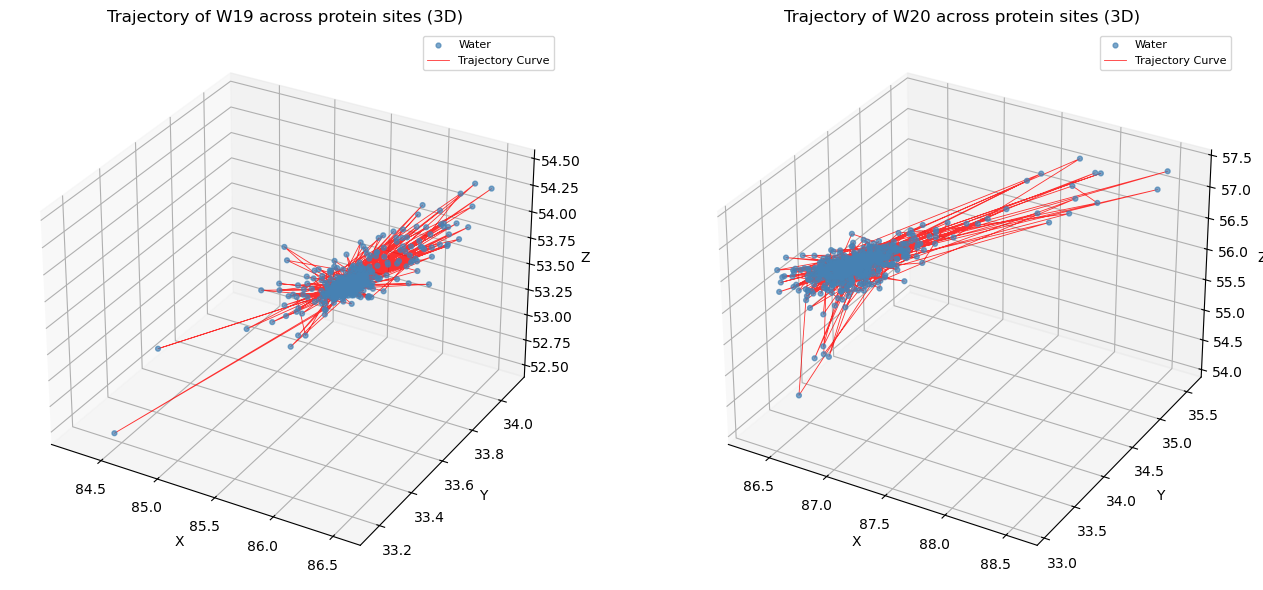

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def coords_from_pdb(pdb_path, atom_name=None):
    """Grab every atom's coordinates from a PDB, in file order."""
    coords = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith(('ATOM', 'HETATM')):
                name = line[12:16].strip()
                if atom_name is None or name == atom_name:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append((x, y, z))
    return np.array(coords)


def plot_water_trajectory(coords, water_label, ax):
    x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
    ax.scatter(x, y, z, c='steelblue', s=12, alpha=0.7, label='Water')
    ax.plot(x, y, z, c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
    ax.set_title(f'Trajectory of {water_label} across protein sites (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend(loc='upper right', fontsize=8)


coords_W19 = coords_from_pdb('water_pdbs/O4/W19.pdb')
coords_W20 = coords_from_pdb('water_pdbs/O4/W20.pdb')

print('W19:', coords_W19.shape)   # should be (n_frames, 3)
print('W20:', coords_W20.shape)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_water_trajectory(coords_W19, 'W19', ax1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_water_trajectory(coords_W20, 'W20', ax2)
plt.tight_layout()
plt.savefig('/Users/yyklab/Downloads/W19_W20_trajectories.png', dpi=150)
plt.show()

## Walk Animation

W19: (711, 3)
W20: (648, 3)
saved W19_W20_walk.gif


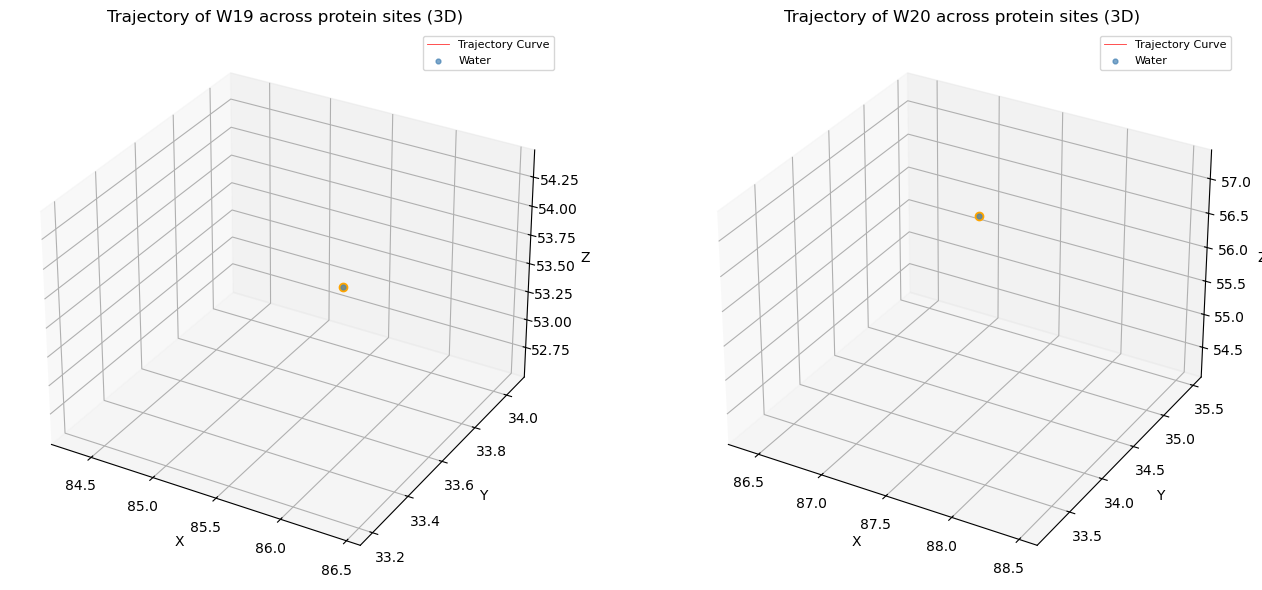

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def coords_from_pdb(pdb_path, atom_name=None):
    """Grab every atom's coordinates from a PDB, in file order."""
    coords = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith(('ATOM', 'HETATM')):
                name = line[12:16].strip()
                if atom_name is None or name == atom_name:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append((x, y, z))
    return np.array(coords)


coords_W19 = coords_from_pdb('water_pdbs/O4/W19.pdb')
coords_W20 = coords_from_pdb('water_pdbs/O4/W20.pdb')

print('W19:', coords_W19.shape)
print('W20:', coords_W20.shape)


def setup_axis(ax, coords, water_label):
    """Fix the axis limits/labels up front so they don't jump around as the trail grows."""
    ax.set_xlim(coords[:, 0].min(), coords[:, 0].max())
    ax.set_ylim(coords[:, 1].min(), coords[:, 1].max())
    ax.set_zlim(coords[:, 2].min(), coords[:, 2].max())
    ax.set_title(f'Trajectory of {water_label} across protein sites (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
setup_axis(ax1, coords_W19, 'W19')
setup_axis(ax2, coords_W20, 'W20')

# artists we'll update each frame: the growing red line, all-visited dots, and the current position
line1, = ax1.plot([], [], [], c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
dots1 = ax1.scatter([], [], [], c='steelblue', s=12, alpha=0.7, label='Water')
head1, = ax1.plot([], [], [], 'o', c='orange', markersize=6)

line2, = ax2.plot([], [], [], c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
dots2 = ax2.scatter([], [], [], c='steelblue', s=12, alpha=0.7, label='Water')
head2, = ax2.plot([], [], [], 'o', c='orange', markersize=6)

ax1.legend(loc='upper right', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# animate up to the length of the longer trajectory
n_frames = max(len(coords_W19), len(coords_W20))

def update(i):
    for coords, line, dots, head in [
        (coords_W19, line1, dots1, head1),
        (coords_W20, line2, dots2, head2),
    ]:
        k = min(i + 1, len(coords))   # clamp for the shorter trajectory
        sub = coords[:k]
        line.set_data(sub[:, 0], sub[:, 1])
        line.set_3d_properties(sub[:, 2])
        dots._offsets3d = (sub[:, 0], sub[:, 1], sub[:, 2])
        head.set_data([sub[-1, 0]], [sub[-1, 1]])
        head.set_3d_properties([sub[-1, 2]])
    return line1, dots1, head1, line2, dots2, head2

anim = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=False)

plt.tight_layout()
anim.save('/Users/yyklab/Downloads/W19_W20_walk.gif', writer=PillowWriter(fps=20))
print('saved W19_W20_walk.gif')

### Entry/Exit 


Reading reference PDB: /Users/yyklab/Desktop/Lab_Files/low_restraints/kinetic_scripts/margaret_files/0F.pdb_fittedto55all.pdb...
Parsing /Users/yyklab/Desktop/Lab_Files/low_restraints/kinetic_scripts/margaret_files/contacts_margaret_50_to_100.txt for entry and exit coordinates...
Performing unique 1-to-1 greedy matching for Entry coordinates...
Performing unique 1-to-1 greedy matching for Exit coordinates...


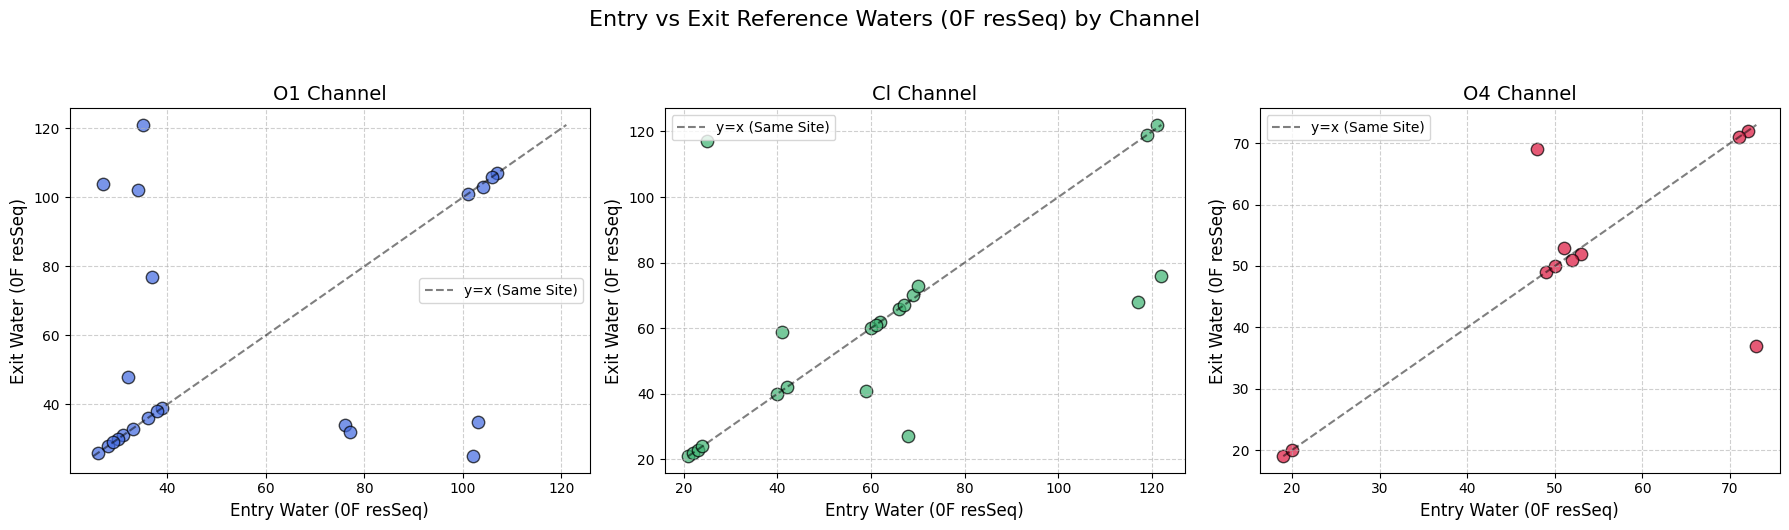

In [8]:
import math
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Configuration ---
REFERENCE_PDB = "/Users/yyklab/Desktop/Lab_Files/low_restraints/kinetic_scripts/margaret_files/0F.pdb_fittedto55all.pdb"
CONTACTS_FILE = "/Users/yyklab/Desktop/Lab_Files/low_restraints/kinetic_scripts/margaret_files/contacts_margaret_50_to_100.txt"

TARGETS = {
    "O1": [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 76, 77, 101, 102, 103, 104, 105, 106, 107, 108],
    "Cl": [59, 60, 66, 67, 68, 69, 70, 21, 22, 23, 24, 25, 61, 62, 40, 41, 42, 150, 117, 119, 121, 122, 150],
    "O4": [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
}

def calc_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

print(f"Reading reference PDB: {REFERENCE_PDB}...")
ref_waters = {}
with open(REFERENCE_PDB, 'r') as f:
    for line in f:
        if line.startswith("HETATM") or line.startswith("ATOM"):
            chain = line[21].strip()
            res_name = line[17:20].strip()
            if chain == 'G' and res_name == 'OOO':
                try:
                    resSeq = int(line[22:26].strip())
                    x = float(line[30:38].strip())
                    y = float(line[38:46].strip())
                    z = float(line[46:54].strip())
                    
                    for channel, res_list in TARGETS.items():
                        if resSeq in res_list:
                            ref_waters[resSeq] = {'coords': (x, y, z), 'channel': channel}
                            break
                except ValueError:
                    pass

# --- 2. Extract First (Entry) and Last (Exit) Coordinates ---
md_bounds = defaultdict(lambda: {
    'min_t1': float('inf'), 'entry_coords': None,
    'max_t2': float('-inf'), 'exit_coords': None
})

print(f"Parsing {CONTACTS_FILE} for entry and exit coordinates...")
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if not line[0].isdigit():
            continue
            
        parts = line.strip().split()
        if len(parts) >= 6:
            w_idx = parts[0]
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            t1, t2 = int(parts[4]), int(parts[5]) # t_start and ts-1 timings[cite: 2]
            
            # Update Entry (lowest t1)
            if t1 < md_bounds[w_idx]['min_t1']:
                md_bounds[w_idx]['min_t1'] = t1
                md_bounds[w_idx]['entry_coords'] = (x, y, z)
                
            # Update Exit (highest t2)
            if t2 > md_bounds[w_idx]['max_t2']:
                md_bounds[w_idx]['max_t2'] = t2
                md_bounds[w_idx]['exit_coords'] = (x, y, z)

# Separate coordinates for processing
all_entry_coords = {w_idx: data['entry_coords'] for w_idx, data in md_bounds.items() if data['entry_coords']}
all_exit_coords = {w_idx: data['exit_coords'] for w_idx, data in md_bounds.items() if data['exit_coords']}

# --- 3. The Greedy 1-to-1 Matching Algorithm ---
# --- 3. The Greedy 1-to-1 Matching Algorithm ---
def greedy_match(ref_dict, target_coords_dict):
    """
    Matches MD coordinates to Reference waters ensuring a unique 1-to-1 match.
    Uses the exact shortest-distance greedy logic provided in the reference script.
    """
    all_pairs = []
    for resSeq, ref_data in ref_dict.items():
        for md_idx, coords in target_coords_dict.items():
            dist = calc_distance(ref_data['coords'], coords)
            all_pairs.append((dist, resSeq, md_idx))
            
    # Sort pairs by distance (shortest first)
    all_pairs.sort(key=lambda x: x[0])

    best_matches = {} 
    claimed_md_ids = set()
    
    for dist, resSeq, md_idx in all_pairs:
        # Guarantee 1-to-1 match uniqueness
        if resSeq not in best_matches and md_idx not in claimed_md_ids:
            best_matches[resSeq] = {'md_idx': md_idx, 'min_dist': dist}
            claimed_md_ids.add(md_idx)
            
        if len(best_matches) == len(ref_dict):
            break
            
    # NEW: Return mapping of md_idx -> dictionary with resSeq and dist
    return {data['md_idx']: {'resSeq': resSeq, 'dist': data['min_dist']} for resSeq, data in best_matches.items()}

# --- 4. Apply Matching Algorithm ---
print("Performing unique 1-to-1 greedy matching for Entry coordinates...")
entry_matches = greedy_match(ref_waters, all_entry_coords)

print("Performing unique 1-to-1 greedy matching for Exit coordinates...")
# To track the flow of the exact same water molecules, we map the exit coordinates 
# of the specific MD waters that were successfully matched during entry.
matched_exit_coords = {md_idx: all_exit_coords[md_idx] for md_idx in entry_matches.keys()}
exit_matches = greedy_match(ref_waters, matched_exit_coords)

# --- 5. Group Data for Plotting ---
plot_data = {channel: {'entry_res': [], 'exit_res': []} for channel in TARGETS.keys()}

for md_idx in exit_matches.keys():
    # ADDED ['resSeq'] HERE to extract just the integer ID
    entry_resSeq = entry_matches[md_idx]['resSeq']
    exit_resSeq = exit_matches[md_idx]['resSeq']
    
    # Group by the channel of the Entry reference water
    channel = ref_waters[entry_resSeq]['channel']
    
    plot_data[channel]['entry_res'].append(entry_resSeq)
    plot_data[channel]['exit_res'].append(exit_resSeq)

# --- 6. Generate Scatter Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Entry vs Exit Reference Waters (0F resSeq) by Channel", fontsize=16, y=1.05)

colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}

for ax, (channel, data) in zip(axes, plot_data.items()):
    # Scatter plot
    ax.scatter(data['entry_res'], data['exit_res'], 
               c=colors[channel], alpha=0.7, edgecolors='k', s=80)
    
    # Formatting
    ax.set_title(f"{channel} Channel", fontsize=14)
    ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
    ax.set_ylabel("Exit Water (0F resSeq)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add a y=x diagonal line 
    all_res = data['entry_res'] + data['exit_res']
    if all_res:
        min_val, max_val = min(all_res), max(all_res)
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='y=x (Same Site)')
        ax.legend()

plt.tight_layout()
plt.show()

### Combine Graphs

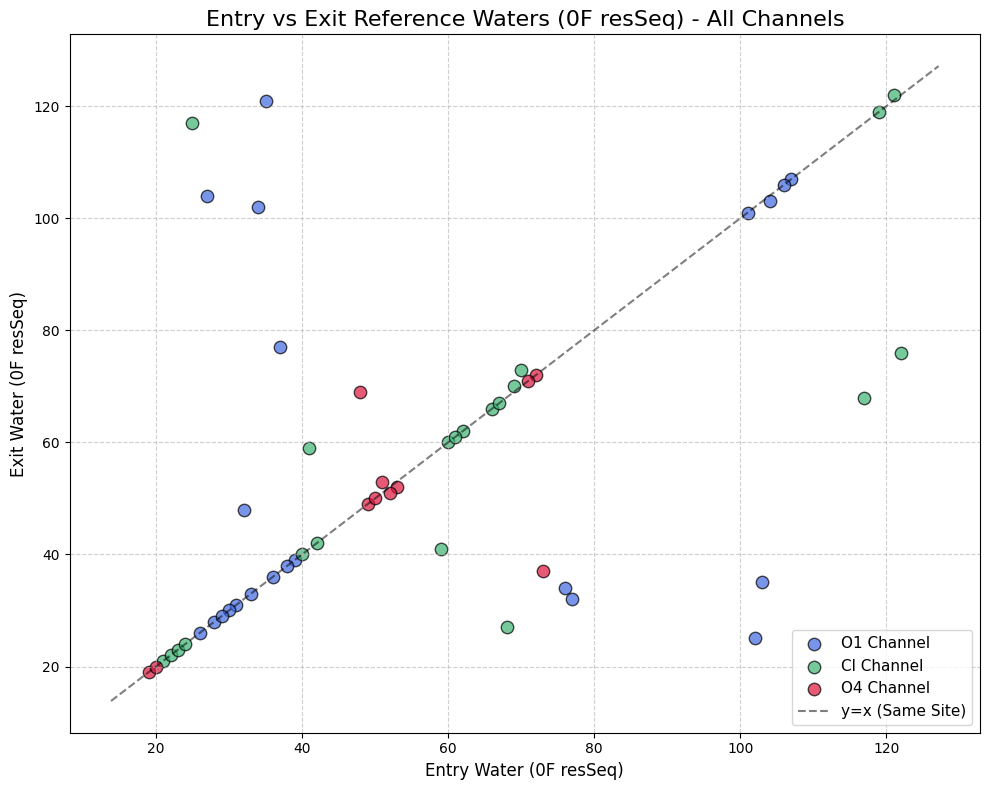

In [9]:
# --- 6. Generate Combined Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title("Entry vs Exit Reference Waters (0F resSeq) - All Channels", fontsize=16)

colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}
all_res_global = [] # Store all coordinates to draw an accurate y=x reference line

for channel, data in plot_data.items():
    if data['entry_res']:
        # Scatter plot for each channel on the SAME axes
        ax.scatter(data['entry_res'], data['exit_res'], 
                   c=colors[channel], alpha=0.7, edgecolors='k', s=80, label=f"{channel} Channel")
        
        # Accumulate all values to calculate the min/max bounds later
        all_res_global.extend(data['entry_res'] + data['exit_res'])

# Formatting the combined plot
ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
ax.set_ylabel("Exit Water (0F resSeq)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Add a single y=x diagonal line representing identical entry/exit sites
if all_res_global:
    min_val, max_val = min(all_res_global), max(all_res_global)
    padding = (max_val - min_val) * 0.05 if max_val != min_val else 5
    ax.plot([min_val - padding, max_val + padding], 
            [min_val - padding, max_val + padding], 
            'k--', alpha=0.5, label='y=x (Same Site)')

# Display the legend to differentiate the channels
ax.legend(fontsize=11, loc="best")

plt.tight_layout()
plt.show()

### Single Graph

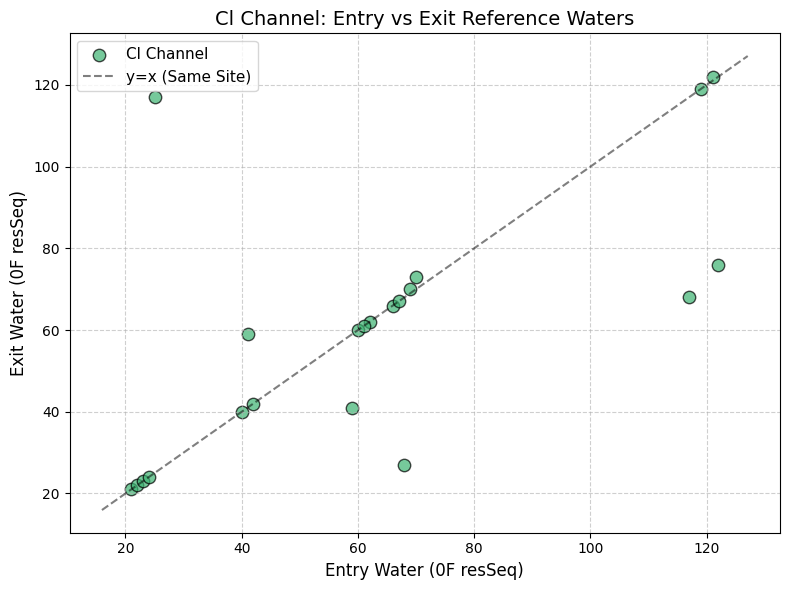

In [10]:
# Change this variable to "O1", "Cl", or "O4" to view a different channel
CHANNEL_TO_PLOT = "Cl" 

# --- 6. Generate Single Channel Scatter Plot ---
if CHANNEL_TO_PLOT not in plot_data:
    print(f"Error: '{CHANNEL_TO_PLOT}' is not a valid channel. Please choose from {list(plot_data.keys())}.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    data = plot_data[CHANNEL_TO_PLOT]
    colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}
    
    if not data['entry_res']:
        print(f"No matching data found for the {CHANNEL_TO_PLOT} channel.")
    else:
        # Scatter plot for just the selected channel
        ax.scatter(data['entry_res'], data['exit_res'], 
                   c=colors.get(CHANNEL_TO_PLOT, 'black'), alpha=0.7, edgecolors='k', s=80, label=f"{CHANNEL_TO_PLOT} Channel")
        
        # Formatting
        ax.set_title(f"{CHANNEL_TO_PLOT} Channel: Entry vs Exit Reference Waters", fontsize=14)
        ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
        ax.set_ylabel("Exit Water (0F resSeq)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Add a y=x diagonal line 
        all_res = data['entry_res'] + data['exit_res']
        if all_res:
            min_val, max_val = min(all_res), max(all_res)
            
            # Extend the line slightly past the min/max values for better visibility
            padding = (max_val - min_val) * 0.05 if max_val != min_val else 5
            ax.plot([min_val - padding, max_val + padding], 
                    [min_val - padding, max_val + padding], 
                    'k--', alpha=0.5, label='y=x (Same Site)')
            
        ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

In [11]:
CHANNEL_TO_PLOT = "O1" 

print(f"--- Tracking Data for Channel: {CHANNEL_TO_PLOT} ---")
# Added columns for Entry and Exit Distances
print(f"{'MD Water ID':<15} | {'Entry resSeq':<12} | {'Entry Dist (Å)':<15} | {'Exit resSeq':<12} | {'Exit Dist (Å)':<15}")
print("-" * 79)

for md_idx in exit_matches.keys():
    # Extract resSeq and dist for Entry
    entry_resSeq = entry_matches[md_idx]['resSeq']
    entry_dist = entry_matches[md_idx]['dist']
    
    # Extract resSeq and dist for Exit
    exit_resSeq = exit_matches[md_idx]['resSeq']
    exit_dist = exit_matches[md_idx]['dist']
    
    channel = ref_waters[entry_resSeq]['channel']
    
    if channel == CHANNEL_TO_PLOT:
        # Formatted distances to 3 decimal places
        print(f"{md_idx:<15} | {entry_resSeq:<12} | {entry_dist:<15.3f} | {exit_resSeq:<12} | {exit_dist:<15.3f}")

--- Tracking Data for Channel: O1 ---
MD Water ID     | Entry resSeq | Entry Dist (Å)  | Exit resSeq  | Exit Dist (Å)  
-------------------------------------------------------------------------------
434902          | 31           | 0.326           | 31           | 0.308          
434893          | 30           | 0.625           | 30           | 0.484          
411463          | 101          | 0.762           | 101          | 0.587          
434905          | 28           | 0.608           | 28           | 0.602          
434899          | 29           | 0.748           | 29           | 0.683          
698530          | 36           | 0.825           | 36           | 0.702          
698539          | 103          | 0.573           | 35           | 0.862          
434890          | 26           | 0.904           | 26           | 0.953          
434911          | 33           | 0.727           | 33           | 0.998          
434908          | 39           | 1.010           | 39         

In [ ]:
target_entry = 102  
target_exit = 26   

channel_data = plot_data[CHANNEL_TO_PLOT]
found_ids = []

for i in range(len(channel_data['entry_res'])):
    if channel_data['entry_res'][i] == target_entry and channel_data['exit_res'][i] == target_exit:
        found_ids.append(channel_data['md_id'][i])

if found_ids:
    print(f"MD Water ID(s) for point (Entry: {target_entry}, Exit: {target_exit}):")
    for w_id in found_ids:
        print(f" -> {w_id}")
else:
    print("No water found at those coordinates.")

No water found at those coordinates.


## RMSD of Channels

 {len(coords)} total contacts
Found 8435 waters in O4

RMSD for 41 distinct water molecules.
Average RMSD for O4 waters: 0.61 Å
Lowest-RMSD (most confined) water:  ID 780550 (0.05 Å)
Highest-RMSD (most mobile) water:   ID 434959 (2.56 Å)

Saved histogram to: RMSD_hist_O4.png


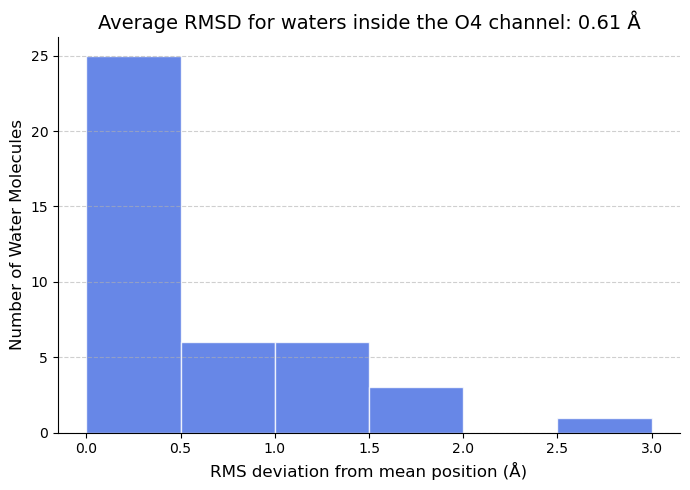

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
#  Configuration
# ============================================================
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"
CAVER_PDB     = "/Users/yyklab/Downloads/O4.pdb"  # Update this to your caver channel PDB
CHANNEL_NAME  = "O4"

# CAVER profiles often define the void space. You may need to add the 
# radius of a water molecule (~1.4 Å) to the caver sphere radius to accurately 
# capture the center of oxygen atoms touching the channel boundary.
WATER_PROBE_RADIUS = 1.4 

# ============================================================
# 1. Load the Caver Channel Profile
# ============================================================
def load_caver_spheres(pdb_filename):

    spheres = []
    with open(pdb_filename, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                x = float(line[30:38].strip())
                y = float(line[38:46].strip())
                z = float(line[46:54].strip())
                # Radius is typically in the B-factor column
                r = float(line[60:66].strip()) 
                spheres.append([x, y, z, r])
    return np.array(spheres)

caver_spheres = load_caver_spheres(CAVER_PDB)

# ============================================================
# 2. Parse Contacts and Find "Inside" Waters
# ============================================================
water_ids = []
coords = []

# Read all contact coordinates into memory
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if line[0].isdigit():
            parts = line.strip().split()
            if len(parts) >= 4:
                # We extract the water id and its x, y, z coordinates[cite: 2]
                widx = int(parts[0])
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                
                water_ids.append(widx)
                coords.append([x, y, z])

water_ids = np.array(water_ids)
coords = np.array(coords)

print(" {len(coords)} total contacts")

inside_mask = np.zeros(len(coords), dtype=bool)

for cx, cy, cz, r in caver_spheres:
    # Calculate squared distance to avoid expensive square root operations
    dist_sq = (coords[:, 0] - cx)**2 + (coords[:, 1] - cy)**2 + (coords[:, 2] - cz)**2
    # Check if inside this specific sphere's radius
    effective_radius = r + WATER_PROBE_RADIUS
    inside_mask |= (dist_sq <= effective_radius**2)

# Filter arrays to only keep points strictly inside the Caver volume
inside_wids = water_ids[inside_mask]
inside_coords = coords[inside_mask]
print(f"Found {len(inside_coords)} waters in {CHANNEL_NAME}")

# ============================================================
# 3. Calculate RMSD for Each Water 
# ============================================================
# Group the inside-channel coordinates by water index
water_points = defaultdict(list)
for wid, coord in zip(inside_wids, inside_coords):
    water_points[wid].append(coord)

rmsd_values = []
valid_waters = []

for wid, pts in water_points.items():
    pts_array = np.array(pts)
    
    # We need at least 2 points inside the channel to calculate a meaningful RMSD
    if len(pts_array) >= 2:
        # 1. Find the centroid (mean position) of the water while in the channel
        centroid = pts_array.mean(axis=0)
        
        # 2. Calculate RMS deviation from that centroid
        # RMSD = sqrt( mean( sum( (points - centroid)^2 ) ) )
        rmsd = np.sqrt(np.mean(np.sum((pts_array - centroid)**2, axis=1)))
        
        rmsd_values.append(rmsd)
        valid_waters.append(wid)

rmsd_values = np.array(rmsd_values)

if len(rmsd_values) == 0:
    print("Error: Not enough data points fell inside the channel to calculate RMSD.")
else:
    avg_rmsd = rmsd_values.mean()
    print(f"\nRMSD for {len(rmsd_values)} distinct water molecules.")
    print(f"Average RMSD for {CHANNEL_NAME} waters: {avg_rmsd:.2f} Å")
    
    # Identify extreme behaviors
    order = np.argsort(rmsd_values)
    print(f"Lowest-RMSD (most confined) water:  ID {valid_waters[order[0]]} ({rmsd_values[order[0]]:.2f} Å)")
    print(f"Highest-RMSD (most mobile) water:   ID {valid_waters[order[-1]]} ({rmsd_values[order[-1]]:.2f} Å)")

    # ============================================================
    # 4. Plot Histogram
    # ============================================================
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Generate bins dynamically based on the maximum RMSD
    bins = np.arange(0, np.ceil(rmsd_values.max()) + .5, 0.5)
    
    ax.hist(rmsd_values, bins=bins, color="royalblue", edgecolor="white", alpha=0.8)
    
    ax.set_xlabel("RMS deviation from mean position (Å)", fontsize=12)
    ax.set_ylabel("Number of Water Molecules", fontsize=12)
    ax.set_title(f"Average RMSD for waters inside the {CHANNEL_NAME} channel: {avg_rmsd:.2f} Å", fontsize=14)
    
    # Clean up aesthetics
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    output_filename = f"RMSD_hist_{CHANNEL_NAME}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nSaved histogram to: {output_filename}")
    plt.show()

### Histogram of Time Spent

 7484236 total contacts

Calculated residence times for 117 distinct water molecules.
Average time spent in O4: 4.848 ns
Maximum time spent in O4: 44.876 ns

 Residence_Time_hist_O4.png


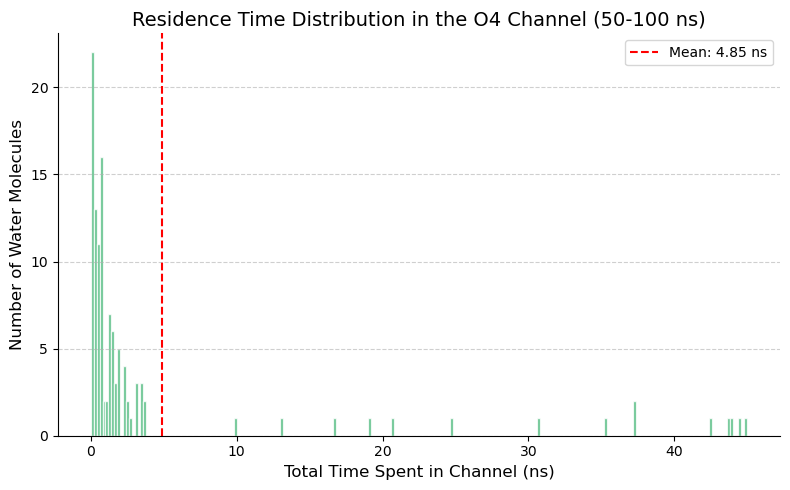

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
#  Configuration
# ============================================================
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"
CAVER_PDB     = "/Users/yyklab/Downloads/O4.pdb"  
CHANNEL_NAME  = "O4"

# 1.4 Å represents the approximate radius of a water molecule
WATER_PROBE_RADIUS = 1.4 

# Time conversion: based on your previous code, 1 frame = 2.0 ps.
# 2.0 ps = 0.002 ns.
DT_NS = 0.002 

# ============================================================
# 1. Load the Caver Channel Profile
# ============================================================
def load_caver_spheres(pdb_filename):
    spheres = []
    with open(pdb_filename, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                x = float(line[30:38].strip())
                y = float(line[38:46].strip())
                z = float(line[46:54].strip())
                r = float(line[60:66].strip()) 
                spheres.append([x, y, z, r])
    return np.array(spheres)

caver_spheres = load_caver_spheres(CAVER_PDB)

# ============================================================
# 2. Parse Contacts and Find "Inside" Waters
# ============================================================
water_ids = []
coords = []
durations = []

with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if line[0].isdigit():
            parts = line.strip().split()
            if len(parts) >= 6:
                widx = int(parts[0])
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                t1 = int(parts[4]) # t_start[cite: 2]
                t2 = int(parts[5]) # ts-1[cite: 2]
                
                water_ids.append(widx)
                coords.append([x, y, z])
                
                # Calculate the duration of this specific contact episode in frames
                durations.append(t2 - t1)

water_ids = np.array(water_ids)
coords = np.array(coords)
durations = np.array(durations)

print(f" {len(coords)} total contacts")

# Vectorized spatial inclusion check
inside_mask = np.zeros(len(coords), dtype=bool)

for cx, cy, cz, r in caver_spheres:
    dist_sq = (coords[:, 0] - cx)**2 + (coords[:, 1] - cy)**2 + (coords[:, 2] - cz)**2
    effective_radius = r + WATER_PROBE_RADIUS
    inside_mask |= (dist_sq <= effective_radius**2)

# Filter arrays to only keep episodes strictly inside the Caver volume
inside_wids = water_ids[inside_mask]
inside_durations = durations[inside_mask]

# ============================================================
# 3. Calculate Total Time Spent per Unique Water
# ============================================================
# A single water might bounce around and have multiple contact episodes 
# inside the channel. We want to sum the total time spent per unique water ID.
total_frames_per_water = defaultdict(int)

for wid, duration in zip(inside_wids, inside_durations):
    total_frames_per_water[wid] += duration

# Convert frames to nanoseconds
times_ns = []
for wid, total_frames in total_frames_per_water.items():
    times_ns.append(total_frames * DT_NS)

times_ns = np.array(times_ns)

if len(times_ns) == 0:
    print(f"Error: No waters found inside the {CHANNEL_NAME} channel.")
else:
    avg_time = times_ns.mean()
    max_time = times_ns.max()
    
    print(f"\nCalculated residence times for {len(times_ns)} distinct water molecules.")
    print(f"Average time spent in {CHANNEL_NAME}: {avg_time:.3f} ns")
    print(f"Maximum time spent in {CHANNEL_NAME}: {max_time:.3f} ns")

    # ============================================================
    # 4. Plot Histogram
    # ============================================================
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Create bins. Adjust the step size (0.5 ns) if your data range is very small or very large
    bin_width = 0.2 
    bins = np.arange(0, np.ceil(max_time) + bin_width, bin_width)
    
    ax.hist(times_ns, bins=bins, color="mediumseagreen", edgecolor="white", alpha=0.8)
    
    ax.set_xlabel("Total Time Spent in Channel (ns)", fontsize=12)
    ax.set_ylabel("Number of Water Molecules", fontsize=12)
    ax.set_title(f"Residence Time Distribution in the {CHANNEL_NAME} Channel (50-100 ns)", fontsize=14)
    
    # Add a vertical line showing the average time
    ax.axvline(avg_time, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {avg_time:.2f} ns')
    ax.legend()
    
    # Clean up aesthetics
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    output_filename = f"Residence_Time_hist_{CHANNEL_NAME}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\n {output_filename}")
    plt.show()